<a href="https://colab.research.google.com/github/silaozturkler/DSA210-sila-ozturkler/blob/main/dsa210sila.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dataset.csv")
df.head()


,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3.3k,475.8m,8.7m,1.39%,6.5m,29.0b,Spain
1,2,kyliejenner,91,6.9k,366.2m,8.3m,1.62%,5.9m,57.4b,United States
2,3,leomessi,90,0.89k,357.3m,6.8m,1.24%,4.4m,6.0b,NaN
3,4,selenagomez,93,1.8k,342.7m,6.2m,0.97%,3.3m,11.5b,United States
4,5,therock,91,6.8k,334.1m,1.9m,0.20%,665.3k,12.5b,United States


In [ ]:
def convert_to_number(x):
    if isinstance(x, str):
        x = x.replace(",", "").replace("%", "")
        if "m" in x:
            return float(x.replace("m", "")) * 1_000_000
        elif "k" in x:
            return float(x.replace("k", "")) * 1_000
        else:
            return float(x)
    return x

df["followers"] = df["followers"].apply(convert_to_number)
df["posts"] = df["posts"].apply(convert_to_number)
df["avg_likes"] = df["avg_likes"].apply(convert_to_number)
df["60_day_eng_rate"] = df["60_day_eng_rate"].apply(convert_to_number)

In [ ]:
df.head()

,rank,channel_info,influence_score,posts,followers,avg_likes,60_day_eng_rate,new_post_avg_like,total_likes,country
0,1,cristiano,92,3300.0,475800000.0,8700000.0,1.39,6.5m,29.0b,Spain
1,2,kyliejenner,91,6900.0,366200000.0,8300000.0,1.62,5.9m,57.4b,United States
2,3,leomessi,90,890.0,357300000.0,6800000.0,1.24,4.4m,6.0b,NaN
3,4,selenagomez,93,1800.0,342700000.0,6200000.0,0.97,3.3m,11.5b,United States
4,5,therock,91,6800.0,334100000.0,1900000.0,0.20,665.3k,12.5b,United States


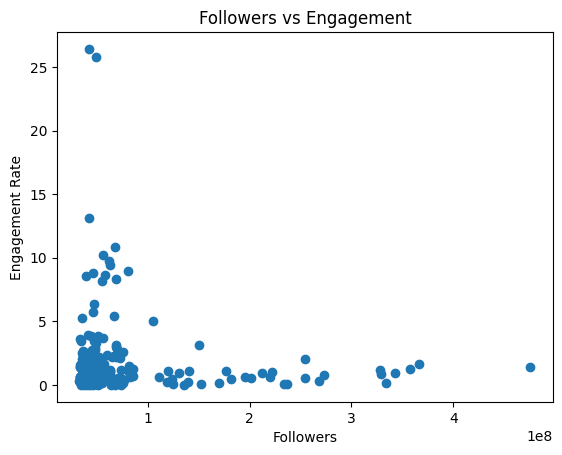

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["followers"], df["60_day_eng_rate"])
plt.xlabel("Followers")
plt.ylabel("Engagement Rate")
plt.title("Followers vs Engagement")
plt.show()

In [ ]:
df["engagement_per_post"] = df["avg_likes"] / df["posts"]
df["normalized_engagement"] = df["avg_likes"] / df["followers"]

In [ ]:
df = df.dropna()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["followers", "posts", "avg_likes"]]
y = df["60_day_eng_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.linear_model import LogisticRegression

df["high_engagement"] = df["60_day_eng_rate"] > df["60_day_eng_rate"].median()

X = df[["followers", "posts", "avg_likes"]]
y = df["high_engagement"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

I applied machine learning methods to analyze Instagram influencer engagement. First, I used a regression model to predict 60-day engagement rate based on followers, posts, and average likes. Then, I created a classification variable to divide influencers into high and low engagement groups based on the median engagement rate.

The results suggest that influencer-related features can be used to model engagement, although engagement may also depend on other factors such as content type, posting time, and audience behavior.


## Hypothesis

H0: Followers have no effect on engagement rate.

H1: Followers significantly affect engagement rate.

In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["followers"], df["60_day_eng_rate"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.09396691857890811
P-value: 0.2729701299848299


## Hypothesis Result

There is a very weak and slightly negative relationship between followers and engagement rate.

The p-value is greater than 0.05, which means the result is not statistically significant.

So, we cannot reject H0. This suggests that the number of followers does not have a clear effect on engagement rate.

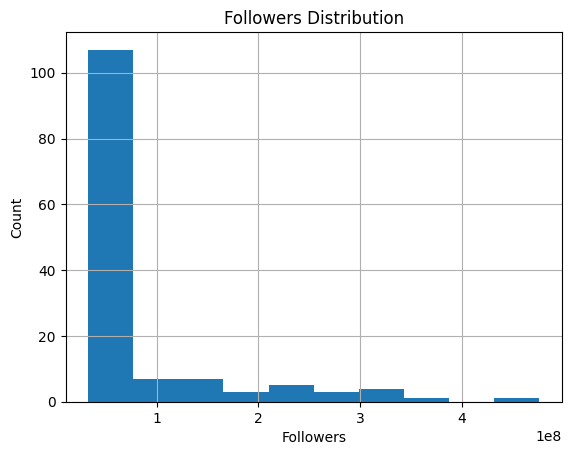

In [ ]:
import matplotlib.pyplot as plt

df["followers"].hist()
plt.title("Followers Distribution")
plt.xlabel("Followers")
plt.ylabel("Count")
plt.show()

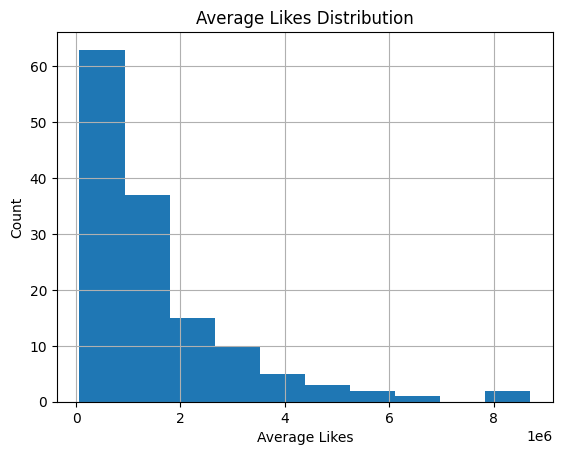

In [ ]:
df["avg_likes"].hist()
plt.title("Average Likes Distribution")
plt.xlabel("Average Likes")
plt.ylabel("Count")
plt.show()

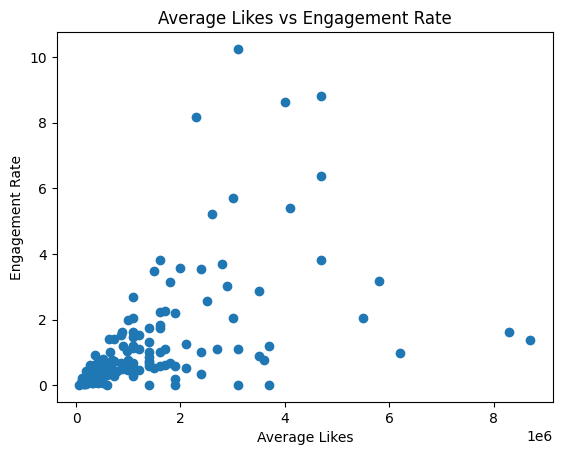

In [ ]:
plt.scatter(df["avg_likes"], df["60_day_eng_rate"])
plt.xlabel("Average Likes")
plt.ylabel("Engagement Rate")
plt.title("Average Likes vs Engagement Rate")
plt.show()

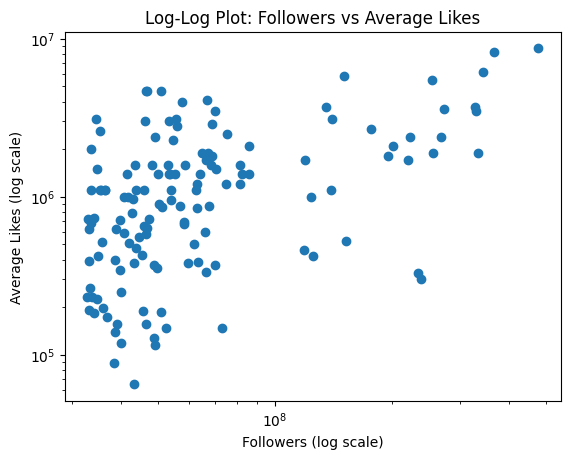

In [ ]:
plt.scatter(df["followers"], df["avg_likes"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Followers (log scale)")
plt.ylabel("Average Likes (log scale)")
plt.title("Log-Log Plot: Followers vs Average Likes")
plt.show()

## Hypotheses

H1: Followers are related to average likes.

H2: Average likes are related to engagement rate.

H3: Number of posts is related to engagement rate.

In [ ]:
from scipy.stats import pearsonr

variables = [
    ("followers", "avg_likes"),
    ("avg_likes", "60_day_eng_rate"),
    ("posts", "60_day_eng_rate")
]

for x, y in variables:
    corr, p_value = pearsonr(df[x], df[y])
    print(x, "vs", y)
    print("Correlation:", corr)
    print("P-value:", p_value)
    print()


followers vs avg_likes
Correlation: 0.6103471022359912
P-value: 1.9066393263972855e-15

avg_likes vs 60_day_eng_rate
Correlation: 0.49504503722883225
P-value: 6.732649543986029e-10

posts vs 60_day_eng_rate
Correlation: -0.3578780456486616
P-value: 1.636317625545569e-05



In [ ]:
from scipy.stats import pearsonr

variables = [
    ("followers", "avg_likes"),
    ("avg_likes", "60_day_eng_rate"),
    ("posts", "60_day_eng_rate")
]

for x, y in variables:
    corr, p_value = pearsonr(df[x], df[y])
    print(x, "vs", y)
    print("Correlation:", corr)
    print("P-value:", p_value)
    print()

followers vs avg_likes
Correlation: 0.6103471022359912
P-value: 1.9066393263972855e-15

avg_likes vs 60_day_eng_rate
Correlation: 0.49504503722883225
P-value: 6.732649543986029e-10

posts vs 60_day_eng_rate
Correlation: -0.3578780456486616
P-value: 1.636317625545569e-05



The plots show that the dataset has strong outliers, especially in followers and average likes. Because of this, I used a log-log plot to see the relationship more clearly.

The hypothesis tests show which variables have a statistically meaningful relationship with engagement.